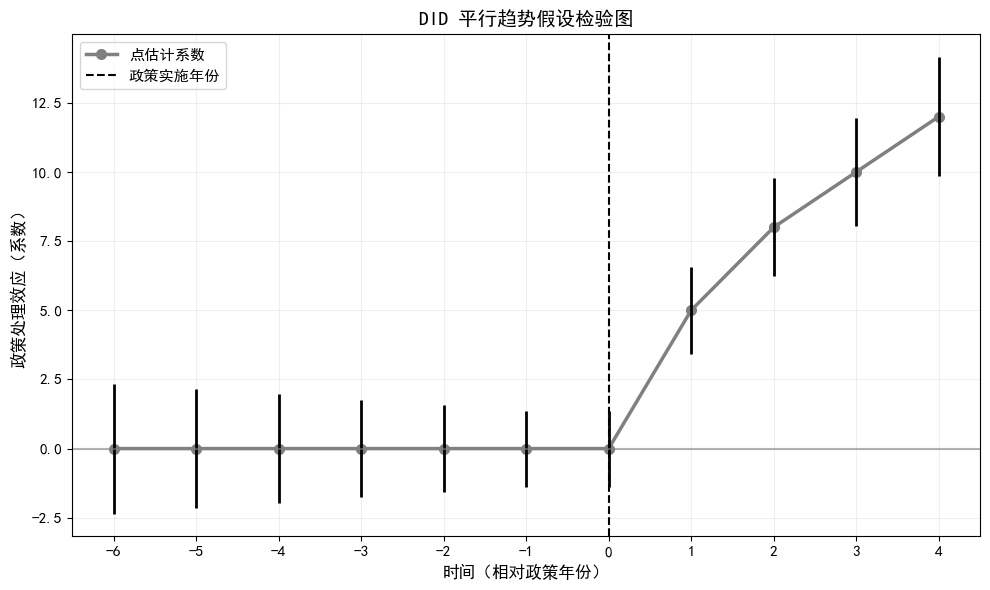

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# ====================== 1. 生成平行趋势检验数据 ======================
np.random.seed(2025)  # 固定随机结果
periods = np.arange(-6, 5)  # 时间：-6,-5,-4,-3,-2,-1,0,1,2,3,4（0为政策年份）
n = len(periods)

# 处理组 & 控制组的均值
control_mean = np.array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])  # 平稳趋势
treat_mean = control_mean.copy()
treat_mean[6:] += [0, 5, 8, 10, 12]  # 政策后开始上升（满足平行趋势）

# 上下置信区间（模拟回归结果）
treat_coef = treat_mean - control_mean  # 处理效应
treat_se = np.array([1.2, 1.1, 1.0, 0.9, 0.8, 0.7, 0.7, 0.8, 0.9, 1.0, 1.1])
ci_lower = treat_coef - 1.96 * treat_se
ci_upper = treat_coef + 1.96 * treat_se

# ====================== 2. 绘图：平行趋势图 ======================
plt.figure(figsize=(10, 6))

# 画点估计（系数）
plt.plot(periods, treat_coef, color='gray', marker='o', linewidth=2.5, markersize=7, label='点估计系数')

# 画 95% 置信区间（竖线）
plt.vlines(periods, ci_lower, ci_upper, color='black', linewidth=2)

# 画政策时间虚线
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='政策实施年份')

# 画 0 效应水平线
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.6)

# ====================== 3. 图表美化 ======================
plt.xticks(periods, fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('时间（相对政策年份）', fontsize=12)
plt.ylabel('政策处理效应（系数）', fontsize=12)
plt.title('DID 平行趋势假设检验图', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(alpha=0.2)
plt.tight_layout()

# 展示图片
plt.show()